In [1]:
!pip install scikit-learn

In [2]:
# !pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121
# 

In [2]:
import pandas as pd
import os 
import numpy as np


df=pd.read_csv("./data/"+os.listdir("./data")[0])
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y')
df = df.sort_values(['store', 'item', 'date'])

# Date features
df['day_of_week']    = df['date'].dt.dayofweek
df['month']          = df['date'].dt.month
df['quarter']        = df['date'].dt.quarter
df['is_weekend']     = (df['day_of_week'] >= 5).astype(int)
df['is_month_start'] = (df['date'].dt.day <= 5).astype(int)
df['is_month_end']   = (df['date'].dt.day >= 25).astype(int)

# Lag features — grouped by store and item
grp = df.groupby(['store', 'item'])['sales']
df['lag_7']          = grp.shift(7)
df['lag_14']         = grp.shift(14)
df['lag_30']         = grp.shift(30)
df['lag_365']        = grp.shift(365)

# Rolling features
df['rolling_mean_7'] = grp.shift(1).rolling(7).mean()
df['rolling_mean_30']= grp.shift(1).rolling(30).mean()
df['rolling_mean_90']= grp.shift(1).rolling(90).mean()
df['rolling_std_7']  = grp.shift(1).rolling(7).std()

# Trend and growth
df['trend_direction']= df['lag_7'] - df['lag_30']
df['yoy_growth']     = (df['lag_7'] - df['lag_365']) / (df['lag_365'] + 1)

# Target
df['sales_next_7']   = grp.shift(-7).rolling(7).sum()

df.dropna(inplace=True)

# Final columns
FEATURES = ['day_of_week','month','quarter','is_weekend',
            'is_month_start','is_month_end','lag_7','lag_14',
            'lag_30','lag_365','rolling_mean_7','rolling_mean_30',
            'rolling_mean_90','rolling_std_7',
            'trend_direction','yoy_growth']
TARGET = 'sales_next_7'

X = df[FEATURES].values
y = df[TARGET].values


In [3]:
df


,date,store,item,sales,day_of_week,month,quarter,is_weekend,is_month_start,is_month_end,...,lag_14,lag_30,lag_365,rolling_mean_7,rolling_mean_30,rolling_mean_90,rolling_std_7,trend_direction,yoy_growth,sales_next_7
365,2014-01-01,1,1,9,2,1,1,0,1,0,...,18.0,8.0,13.0,13.000000,12.400000,15.788889,5.291503,-2.0,-0.500000,99.0
366,2014-01-02,1,1,14,3,1,1,0,1,0,...,7.0,21.0,11.0,13.428571,12.433333,15.733333,4.720775,-5.0,0.416667,102.0
367,2014-01-03,1,1,11,4,1,1,0,1,0,...,13.0,6.0,14.0,13.142857,12.200000,15.733333,4.598136,12.0,0.266667,103.0
368,2014-01-04,1,1,20,5,1,1,1,1,0,...,11.0,13.0,13.0,12.142857,12.366667,15.700000,4.099942,4.0,0.285714,100.0
369,2014-01-05,1,1,17,6,1,1,1,1,0,...,9.0,15.0,10.0,12.571429,12.600000,15.700000,4.790864,-1.0,0.363636,95.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
912988,2017-12-20,10,50,51,2,12,4,0,0,0,...,60.0,62.0,58.0,65.142857,69.833333,79.777778,12.759684,5.0,0.152542,439.0
912989,2017-12-21,10,50,63,3,12,4,0,0,0,...,66.0,81.0,64.0,62.857143,69.466667,79.355556,13.765035,-9.0,0.123077,435.0
912990,2017-12-22,10,50,75,4,12,4,0,0,0,...,67.0,81.0,56.0,61.571429,68.866667,78.977778,13.176458,-9.0,0.280702,434.0
912991,2017-12-23,10,50,70,5,12,4,1,0,0,...,69.0,87.0,64.0,62.000000,68.666667,78.733333,13.613719,-35.0,-0.184615,426.0


In [4]:
import torch
import torch.nn as nn
import numpy as np
import os
import joblib
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}") 


Training on: cuda


Training on: cuda
Starting training on RTX 3060...
Training samples: 581,600 | Test samples: 145,400
------------------------------------------------------------
Epoch  10/300 | Train Loss: 0.0680 | Val Loss: 0.0543
Epoch  20/300 | Train Loss: 0.0349 | Val Loss: 0.0252
Epoch  30/300 | Train Loss: 0.0169 | Val Loss: 0.0154
Epoch  40/300 | Train Loss: 0.0094 | Val Loss: 0.0060
Epoch  50/300 | Train Loss: 0.0065 | Val Loss: 0.0033
Epoch  60/300 | Train Loss: 0.0050 | Val Loss: 0.0018
Epoch  70/300 | Train Loss: 0.0047 | Val Loss: 0.0022
Epoch  80/300 | Train Loss: 0.0043 | Val Loss: 0.0015
Epoch  90/300 | Train Loss: 0.0041 | Val Loss: 0.0014
Epoch 100/300 | Train Loss: 0.0039 | Val Loss: 0.0014
Epoch 110/300 | Train Loss: 0.0037 | Val Loss: 0.0014
Epoch 120/300 | Train Loss: 0.0035 | Val Loss: 0.0014
Epoch 130/300 | Train Loss: 0.0034 | Val Loss: 0.0014
Epoch 140/300 | Train Loss: 0.0032 | Val Loss: 0.0014
Epoch 150/300 | Train Loss: 0.0031 | Val Loss: 0.0013
Epoch 160/300 | Train Loss: 

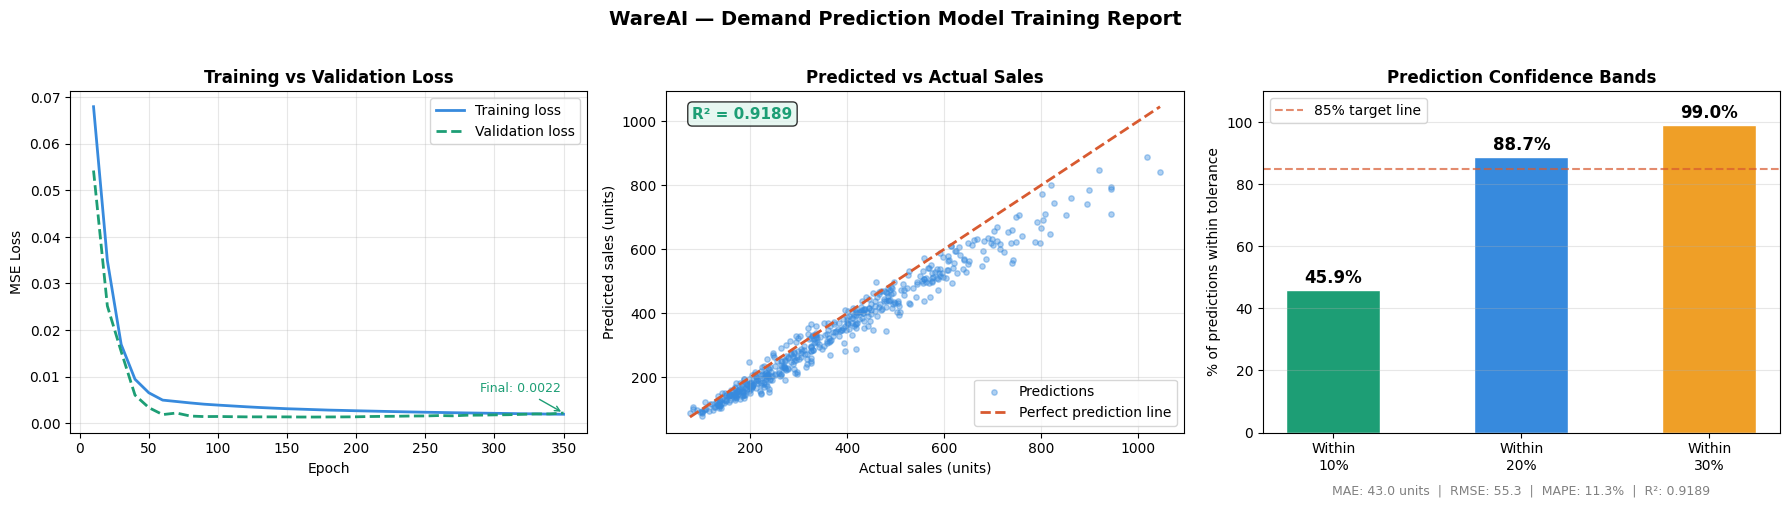


Graph saved: training_report.png
Model saved: demand_model.pth
Scalers saved: scaler_X.pkl, scaler_y.pkl


In [5]:
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

df = pd.read_csv("./data/" + os.listdir("./data")[0])
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y')
df = df.sort_values(['store','item','date'])
grp = df.groupby(['store','item'])['sales']
df['day_of_week']     = df['date'].dt.dayofweek
df['month']           = df['date'].dt.month
df['quarter']         = df['date'].dt.quarter
df['is_weekend']      = (df['day_of_week'] >= 5).astype(int)
df['is_month_start']  = (df['date'].dt.day <= 5).astype(int)
df['is_month_end']    = (df['date'].dt.day >= 25).astype(int)
df['lag_7']           = grp.shift(7)
df['lag_14']          = grp.shift(14)
df['lag_30']          = grp.shift(30)
df['lag_365']         = grp.shift(365)
df['rolling_mean_7']  = grp.shift(1).rolling(7).mean()
df['rolling_mean_30'] = grp.shift(1).rolling(30).mean()
df['rolling_std_7']   = grp.shift(1).rolling(7).std()
df['trend_direction'] = df['lag_7'] - df['lag_30']
df['rolling_mean_90']= grp.shift(1).rolling(90).mean()
df['yoy_growth']      = (df['lag_7'] - df['lag_365']) / (df['lag_365'] + 1)
df['sales_next_7']    = grp.shift(-7).rolling(7).sum()
df.dropna(inplace=True)

FEATURES = ['day_of_week','month','quarter','is_weekend',
            'is_month_start','is_month_end','lag_7','lag_14',
            'lag_30','lag_365','rolling_mean_7','rolling_mean_30',
            'rolling_mean_90','rolling_std_7',
            'trend_direction','yoy_growth']

X = df[FEATURES].values
y = df['sales_next_7'].values

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1,1))

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
X_test_t  = torch.FloatTensor(X_test).to(device)
y_test_t  = torch.FloatTensor(y_test).to(device)

class DemandANN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model = DemandANN(len(FEATURES)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn   = nn.MSELoss()
# ── Replace your training loop with this ─────────────────────────
train_losses = []
val_losses   = []
epochs_log   = []

print("Starting training on RTX 3060...")
print(f"Training samples: {len(X_train):,} | Test samples: {len(X_test):,}")
print("-" * 60)

for epoch in range(350):
    model.train()
    optimizer.zero_grad()
    predictions = model(X_train_t)
    loss        = loss_fn(predictions, y_train_t)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        model.eval()
        with torch.no_grad():
            val_preds = model(X_test_t)
            val_loss  = loss_fn(val_preds, y_test_t)

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())
        epochs_log.append(epoch + 1)

        print(f"Epoch {epoch+1:3d}/300 | "
              f"Train Loss: {loss.item():.4f} | "
              f"Val Loss: {val_loss.item():.4f}")

# ── Metrics same as before ────────────────────────────────────────
print("\n" + "=" * 60)
print("FINAL MODEL EVALUATION")
print("=" * 60)

model.eval()
with torch.no_grad():
    y_pred_scaled = model(X_test_t).cpu().numpy()
    y_true_scaled = y_test_t.cpu().numpy()

y_pred_real = scaler_y.inverse_transform(y_pred_scaled)
y_true_real = scaler_y.inverse_transform(y_true_scaled)

mae      = mean_absolute_error(y_true_real, y_pred_real)
rmse     = np.sqrt(mean_squared_error(y_true_real, y_pred_real))
r2       = r2_score(y_true_real, y_pred_real)
tolerance    = 0.20
within_tol   = np.abs(y_pred_real - y_true_real) <= (tolerance * np.abs(y_true_real))
accuracy_20  = np.mean(within_tol) * 100
mape         = np.mean(np.abs((y_true_real - y_pred_real) / (y_true_real + 1))) * 100

print(f"MAE   (avg units off)    : {mae:.2f} units")
print(f"RMSE  (penalizes spikes) : {rmse:.2f} units")
print(f"R²    (fit score 0-1)    : {r2:.4f}")
print(f"MAPE  (% error avg)      : {mape:.2f}%")
print(f"Accuracy (within 20%)    : {accuracy_20:.2f}%")
print("-" * 60)
print("\nWhat this means:")
print(f"  On average prediction is off by {mae:.1f} units per week")
print(f"  Model explains {r2*100:.1f}% of demand variation")
print(f"  {accuracy_20:.1f}% of predictions are within 20% of actual sales")
if r2 >= 0.85:
    print("  Model quality: EXCELLENT — ready for production")
elif r2 >= 0.70:
    print("  Model quality: GOOD — acceptable for warehouse use")
else:
    print("  Model quality: NEEDS IMPROVEMENT — train more epochs")
print("=" * 60)

# ── Graph 1 — Loss Curve ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('WareAI — Demand Prediction Model Training Report',
             fontsize=14, fontweight='bold', y=1.02)

# Loss curve
axes[0].plot(epochs_log, train_losses, color='#378ADD',
             linewidth=2, label='Training loss')
axes[0].plot(epochs_log, val_losses,   color='#1D9E75',
             linewidth=2, label='Validation loss', linestyle='--')
axes[0].set_title('Training vs Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].annotate(f'Final: {val_losses[-1]:.4f}',
                 xy=(epochs_log[-1], val_losses[-1]),
                 xytext=(-60, 15),
                 textcoords='offset points',
                 fontsize=9,
                 color='#1D9E75',
                 arrowprops=dict(arrowstyle='->', color='#1D9E75'))

# ── Graph 2 — Predicted vs Actual Scatter ────────────────────────
sample_size = min(500, len(y_true_real))
idx         = np.random.choice(len(y_true_real), sample_size, replace=False)
y_sample_true = y_true_real[idx].flatten()
y_sample_pred = y_pred_real[idx].flatten()

axes[1].scatter(y_sample_true, y_sample_pred,
                alpha=0.4, s=15, color='#378ADD', label='Predictions')
min_val = min(y_sample_true.min(), y_sample_pred.min())
max_val = max(y_sample_true.max(), y_sample_pred.max())
axes[1].plot([min_val, max_val], [min_val, max_val],
             color='#D85A30', linewidth=2,
             linestyle='--', label='Perfect prediction line')
axes[1].set_title('Predicted vs Actual Sales', fontweight='bold')
axes[1].set_xlabel('Actual sales (units)')
axes[1].set_ylabel('Predicted sales (units)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].text(0.05, 0.92, f'R² = {r2:.4f}',
             transform=axes[1].transAxes,
             fontsize=11, fontweight='bold', color='#1D9E75',
             bbox=dict(boxstyle='round', facecolor='#E1F5EE', alpha=0.8))

# ── Graph 3 — Confidence / Accuracy Bar ──────────────────────────
# How many predictions fall within 10%, 20%, 30% of actual
thresholds  = [10, 20, 30]
accuracies  = []
colors      = ['#1D9E75', '#378ADD', '#EF9F27']

for t in thresholds:
    within = np.abs(y_pred_real - y_true_real) <= ((t/100) * np.abs(y_true_real))
    accuracies.append(round(np.mean(within) * 100, 2))

bars = axes[2].bar([f'Within\n{t}%' for t in thresholds],
                   accuracies,
                   color=colors,
                   width=0.5,
                   edgecolor='white')

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{acc:.1f}%',
                 ha='center', va='bottom',
                 fontweight='bold', fontsize=12)

axes[2].set_title('Prediction Confidence Bands', fontweight='bold')
axes[2].set_ylabel('% of predictions within tolerance')
axes[2].set_ylim(0, 110)
axes[2].grid(True, alpha=0.3, axis='y')
axes[2].axhline(y=85, color='#D85A30', linestyle='--',
                alpha=0.7, label='85% target line')
axes[2].legend()

# Add model stats as text below bar chart
stats_text = (f'MAE: {mae:.1f} units  |  '
              f'RMSE: {rmse:.1f}  |  '
              f'MAPE: {mape:.1f}%  |  '
              f'R²: {r2:.4f}')
axes[2].text(0.5, -0.18, stats_text,
             transform=axes[2].transAxes,
             ha='center', fontsize=9,
             color='gray')

plt.tight_layout()
plt.savefig('training_report.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nGraph saved: training_report.png")

# ── Save model ────────────────────────────────────────────────────
torch.save(model.state_dict(), 'demand_model.pth')
joblib.dump(scaler_X, 'scaler_X.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')
print("Model saved: demand_model.pth")
print("Scalers saved: scaler_X.pkl, scaler_y.pkl")

In [6]:
def predict_batch(list_of_feature_dicts, horizon='week'):

    FEATURES = ['day_of_week','month','quarter','is_weekend',
                'is_month_start','is_month_end','lag_7','lag_14',
                'lag_30','lag_365','rolling_mean_7','rolling_mean_30',
                'rolling_mean_90','rolling_std_7',
                'trend_direction','yoy_growth']

    # ─────────────────────────────────────────────
    def run_one_pass(feature_dicts):
        all_features = np.array([
            [f[feat] for feat in FEATURES]
            for f in feature_dicts
        ])
        scaled = scaler_X.transform(all_features)
        tensor_in = torch.FloatTensor(scaled).to(device)

        with torch.no_grad():
            raw = model(tensor_in)

        results = scaler_y.inverse_transform(raw.cpu().numpy())
        return [round(float(r[0])) for r in results]

    # ─────────────────────────────────────────────
    def simulate_next_week(feature_dict, weekly_pred):
        f = feature_dict.copy()
        daily_pred = weekly_pred / 7

        # Lag updates
        f['lag_14'] = f['lag_7']
        f['lag_30'] = (f['lag_30'] * 3 + weekly_pred) / 4
        f['lag_7']  = daily_pred

        # Rolling updates
        f['rolling_mean_7']  = (f['rolling_mean_7'] * 6 + daily_pred) / 7
        f['rolling_mean_30'] = (f['rolling_mean_30'] * 29 + daily_pred) / 30

        # Keep stable
        f['rolling_mean_90'] = f['rolling_mean_90']
        f['rolling_std_7']   = f['rolling_std_7']

        # Trend
        f['trend_direction'] = f['lag_7'] - f['lag_30']

        # Date shift
        f['day_of_week'] = (f['day_of_week'] + 7) % 7
        f['is_weekend']  = 1 if f['day_of_week'] >= 5 else 0

        return f

    # ─────────────────────────────────────────────
    # WEEK prediction
    weekly_preds = run_one_pass(list_of_feature_dicts)

    if horizon == 'week':
        return [{'weekly': w} for w in weekly_preds]

    # ─────────────────────────────────────────────
    # MONTH prediction
    monthly_totals   = [0] * len(list_of_feature_dicts)
    weekly_breakdown = [[] for _ in range(len(list_of_feature_dicts))]
    current_features = [f.copy() for f in list_of_feature_dicts]

    for _ in range(4):
        week_preds = run_one_pass(current_features)

        for i, pred in enumerate(week_preds):
            monthly_totals[i] += pred
            weekly_breakdown[i].append(pred)

            current_features[i] = simulate_next_week(current_features[i], pred)

    if horizon == 'month':
        return [
            {'monthly': m, 'weekly_breakdown': wb}
            for m, wb in zip(monthly_totals, weekly_breakdown)
        ]

    if horizon == 'both':
        return [
            {
                'weekly': weekly_preds[i],
                'monthly': monthly_totals[i],
                'weekly_breakdown': weekly_breakdown[i]
            }
            for i in range(len(list_of_feature_dicts))
        ]

    # fallback
    raise ValueError(f"Invalid horizon: {horizon}")


# ── Test all three horizons ───────────────────────────────────────

products = [
    {
        'day_of_week':1,'month':12,'quarter':4,'is_weekend':0,
        'is_month_start':0,'is_month_end':1,'lag_7':48,'lag_14':44,
        'lag_30':41,'lag_365':31,'rolling_mean_7':44.2,'rolling_mean_90':73,
        'rolling_mean_30':39.7,'rolling_std_7':4.1,
        'trend_direction':7.0,'yoy_growth':0.61
    },
    {
        'day_of_week':3,'month':10,'quarter':4,'is_weekend':0,
        'is_month_start':0,'is_month_end':0,'lag_7':80,'lag_14':75,
        'lag_30':60,'lag_365':70,'rolling_mean_7':77.0,
        'rolling_mean_30':65.0,'rolling_mean_90':73,'rolling_std_7':6.2,
        'trend_direction':20.0,'yoy_growth':0.14
    },
    {
        'day_of_week':0,'month':1,'quarter':1,'is_weekend':0,
        'is_month_start':1,'is_month_end':0,'lag_7':20,'lag_14':22,
        'lag_30':25,'lag_365':21,'rolling_mean_7':21.0,'rolling_mean_90':73,
        'rolling_mean_30':23.0,'rolling_std_7':1.8,
        'trend_direction':-5.0,'yoy_growth':-0.05
    }
]

names = ['Wireless Headphones', 'Rice Bags', 'LED Bulbs']

# Get both week and month
results = predict_batch(products, horizon='both')

print("\n" + "="*65)
print("DEMAND PREDICTIONS")
print("="*65)
print(f"{'Product':<25} {'Next Week':>12} {'Next Month':>12} {'Trend':>10}")
print("-"*65)

for name, result in zip(names, results):
    weekly  = result['weekly']
    monthly = result['monthly']
    wb      = result['weekly_breakdown']

    # Detect trend from weekly breakdown
    trend = "rising" if wb[-1] > wb[0] else "falling" if wb[-1] < wb[0] else "stable"

    print(f"{name:<25} {weekly:>10} u  {monthly:>10} u  {trend:>10}")

print("="*65)

# Detailed weekly breakdown
print("\nWEEKLY BREAKDOWN FOR NEXT MONTH")
print("="*65)
print(f"{'Product':<25} {'Week 1':>10} {'Week 2':>10} {'Week 3':>10} {'Week 4':>10}")
print("-"*65)

for name, result in zip(names, results):
    wb = result['weekly_breakdown']
    print(f"{name:<25} {wb[0]:>8} u  {wb[1]:>8} u  {wb[2]:>8} u  {wb[3]:>8} u")

print("="*65)


DEMAND PREDICTIONS
Product                      Next Week   Next Month      Trend
-----------------------------------------------------------------
Wireless Headphones              268 u        1132 u      rising
Rice Bags                        439 u        1880 u      rising
LED Bulbs                        171 u         768 u      rising

WEEKLY BREAKDOWN FOR NEXT MONTH
Product                       Week 1     Week 2     Week 3     Week 4
-----------------------------------------------------------------
Wireless Headphones            268 u       275 u       286 u       303 u
Rice Bags                      439 u       450 u       478 u       513 u
LED Bulbs                      171 u       181 u       197 u       219 u


In [7]:
# df.to_csv("output.csv", index=False)

In [8]:
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def predict_until_date(list_of_feature_dicts, target_date, names=None):
    """
    target_date: string 'YYYY-MM-DD' or datetime object
                 — the future date user selected on slider
    Returns: predictions week by week until that date + graph
    """

    FEATURES = ['day_of_week','month','quarter','is_weekend',
                'is_month_start','is_month_end','lag_7','lag_14',
                'lag_30','lag_365','rolling_mean_7','rolling_mean_30',
                'rolling_std_7','trend_direction','yoy_growth']

    if isinstance(target_date, str):
        target_date = datetime.strptime(target_date, '%Y-%m-%d')

    today        = datetime.today()
    days_ahead   = (target_date - today).days

    if days_ahead <= 0:
        print("Target date must be in the future.")
        return None

    # How many full weeks to predict
    num_weeks    = max(1, round(days_ahead / 7))
    print(f"Predicting {num_weeks} weeks ahead "
          f"({days_ahead} days until {target_date.strftime('%d %b %Y')})")

    # ── Core prediction pass ──────────────────────────────────────
    def run_one_pass(feature_dicts):
        all_features = np.array([
            [f[feat] for feat in FEATURES]
            for f in feature_dicts
        ])
        scaled    = scaler_X.transform(all_features)
        tensor_in = torch.FloatTensor(scaled).to(device)
        with torch.no_grad():
            raw = model(tensor_in)
        results = scaler_y.inverse_transform(raw.cpu().numpy())
        return [round(float(r[0])) for r in results]

    def simulate_next_week(f, weekly_pred):
        f          = f.copy()
        daily_pred = weekly_pred / 7
        f['lag_30']          = f['lag_7']
        f['lag_14']          = f['lag_7']
        f['lag_7']           = daily_pred
        f['rolling_mean_7']  = (f['rolling_mean_7']  * 6  + daily_pred) / 7
        f['rolling_mean_30'] = (f['rolling_mean_30'] * 29 + daily_pred) / 30
        f['trend_direction'] = f['lag_7'] - f['lag_30']
        f['day_of_week']     = (f['day_of_week'] + 7) % 7
        next_month           = f['month'] + 1 if f['month'] < 12 else 1
        f['month']           = next_month
        f['quarter']         = (next_month - 1) // 3 + 1
        f['is_weekend']      = 1 if f['day_of_week'] >= 5 else 0
        f['is_month_start']  = 0
        f['is_month_end']    = 0
        return f

    # ── Run predictions week by week until target date ────────────
    all_results      = []
    current_features = [f.copy() for f in list_of_feature_dicts]

    # Build week date labels
    week_dates = []
    for w in range(num_weeks):
        week_start = today + timedelta(weeks=w)
        week_dates.append(week_start.strftime('%d %b'))

    # Predict each week
    weekly_matrix = [[] for _ in range(len(list_of_feature_dicts))]

    for week_num in range(num_weeks):
        week_preds = run_one_pass(current_features)
        for i, pred in enumerate(week_preds):
            weekly_matrix[i].append(pred)
            current_features[i] = simulate_next_week(current_features[i], pred)

    # Build result dict per product
    for i in range(len(list_of_feature_dicts)):
        wb           = weekly_matrix[i]
        total        = sum(wb)
        peak_week    = wb.index(max(wb)) + 1
        trend        = 'rising'  if wb[-1] > wb[0] else \
                       'falling' if wb[-1] < wb[0] else 'stable'
        all_results.append({
            'weekly_breakdown': wb,
            'total_demand':     total,
            'peak_week':        peak_week,
            'peak_value':       max(wb),
            'trend':            trend,
            'num_weeks':        num_weeks
        })

    # ── Print results ─────────────────────────────────────────────
    pnames = names or [f'Product {i+1}' for i in range(len(list_of_feature_dicts))]

    print("\n" + "="*65)
    print(f"PREDICTIONS UNTIL {target_date.strftime('%d %b %Y').upper()}")
    print("="*65)
    print(f"{'Product':<25} {'Total':>10} {'Peak Week':>12} {'Trend':>10}")
    print("-"*65)
    for name, res in zip(pnames, all_results):
        print(f"{name:<25} {res['total_demand']:>8} u  "
              f"Week {res['peak_week']:>2} ({res['peak_value']} u)  "
              f"{res['trend']:>10}")
    print("="*65)

    # ── Graph ─────────────────────────────────────────────────────
    colors = ['#378ADD', '#1D9E75', '#D85A30', '#EF9F27', '#7F77DD']
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(
        f'Demand forecast until {target_date.strftime("%d %b %Y")} '
        f'({num_weeks} weeks)',
        fontsize=13, fontweight='bold'
    )

    # Graph 1 — Line chart: weekly demand per product
    ax1 = axes[0]
    for i, (name, res) in enumerate(zip(pnames, all_results)):
        wb    = res['weekly_breakdown']
        color = colors[i % len(colors)]
        ax1.plot(week_dates, wb,
                 marker='o', linewidth=2,
                 color=color, label=name, markersize=5)

        # Annotate peak
        peak_idx = wb.index(max(wb))
        ax1.annotate(f"peak {max(wb)}u",
                     xy=(week_dates[peak_idx], max(wb)),
                     xytext=(0, 10), textcoords='offset points',
                     fontsize=8, color=color, ha='center',
                     arrowprops=dict(arrowstyle='->', color=color, lw=1))

    ax1.set_title('Weekly demand trend', fontweight='bold')
    ax1.set_xlabel('Week starting')
    ax1.set_ylabel('Predicted demand (units)')
    ax1.legend(loc='upper left', fontsize=9)
    ax1.grid(True, alpha=0.3)

    # Rotate x labels if many weeks
    if num_weeks > 6:
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

    # Graph 2 — Stacked bar: cumulative per product
    ax2    = axes[1]
    x      = np.arange(len(week_dates))
    bottom = np.zeros(len(week_dates))

    for i, (name, res) in enumerate(zip(pnames, all_results)):
        wb    = np.array(res['weekly_breakdown'])
        color = colors[i % len(colors)]
        bars  = ax2.bar(x, wb, bottom=bottom,
                        color=color, label=name,
                        alpha=0.85, width=0.6)
        bottom += wb

    ax2.set_title('Cumulative weekly demand (all products)', fontweight='bold')
    ax2.set_xlabel('Week starting')
    ax2.set_ylabel('Units')
    ax2.set_xticks(x)
    ax2.set_xticklabels(week_dates,
                        rotation=45 if num_weeks > 6 else 0,
                        ha='right' if num_weeks > 6 else 'center')
    ax2.legend(loc='upper left', fontsize=9)
    ax2.grid(True, alpha=0.3, axis='y')

    # Total label on top of each bar stack
    for xi, total_h in enumerate(bottom):
        ax2.text(xi, total_h + 2, str(int(total_h)),
                 ha='center', va='bottom', fontsize=8,
                 fontweight='bold', color='#444')

    plt.tight_layout()
    filename = f"forecast_until_{target_date.strftime('%Y%m%d')}.png"
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nGraph saved: {filename}")

    return all_results


# ── Test — user drags slider to 3 different future dates ─────────

products = [
    {
        'day_of_week':1,'month':12,'quarter':4,'is_weekend':0,
        'is_month_start':0,'is_month_end':1,'lag_7':48,'lag_14':44,
        'lag_30':41,'lag_365':31,'rolling_mean_7':44.2,
        'rolling_mean_30':39.7,'rolling_std_7':4.1,
        'trend_direction':7.0,'yoy_growth':0.61
    },
    {
        'day_of_week':3,'month':10,'quarter':4,'is_weekend':0,
        'is_month_start':0,'is_month_end':0,'lag_7':80,'lag_14':75,
        'lag_30':60,'lag_365':70,'rolling_mean_7':77.0,
        'rolling_mean_30':65.0,'rolling_std_7':6.2,
        'trend_direction':20.0,'yoy_growth':0.14
    },
    {
        'day_of_week':0,'month':1,'quarter':1,'is_weekend':0,
        'is_month_start':1,'is_month_end':0,'lag_7':20,'lag_14':22,
        'lag_30':25,'lag_365':21,'rolling_mean_7':21.0,
        'rolling_mean_30':23.0,'rolling_std_7':1.8,
        'trend_direction':-5.0,'yoy_growth':-0.05
    }
]

names = ['Wireless Headphones', 'Rice Bags', 'LED Bulbs']

# Slider position 1 — 2 weeks ahead
predict_until_date(products, '2026-04-07', names)

# Slider position 2 — 1 month ahead
predict_until_date(products, '2026-04-24', names)

# Slider position 3 — 3 months ahead
predict_until_date(products, '2026-06-24', names)

Target date must be in the future.
Predicting 1 weeks ahead (6 days until 24 Apr 2026)


ValueError: X has 15 features, but MinMaxScaler is expecting 16 features as input.


SCENARIO: DEMAND SPIKE — Wireless Headphones
Spike: +60% for 14 days
Week             Normal   With Spike   Difference
-----------------------------------------------------------------
Week 1            268 u         429 u        +161 ← SPIKE
Week 2            273 u         483 u        +210 ← SPIKE
Week 3            280 u         338 u         +58
Week 4            293 u         333 u         +40
Week 5            314 u         342 u         +28
Week 6            312 u         336 u         +24
-----------------------------------------------------------------
TOTAL            1740 u        2261 u        +521

Stock analysis (starting stock: 1500 units):
  Without spike → stockout at: Week 6
  With spike    → stockout at: Week 4 ← CRITICAL
  Extra units needed to cover spike: 521 units


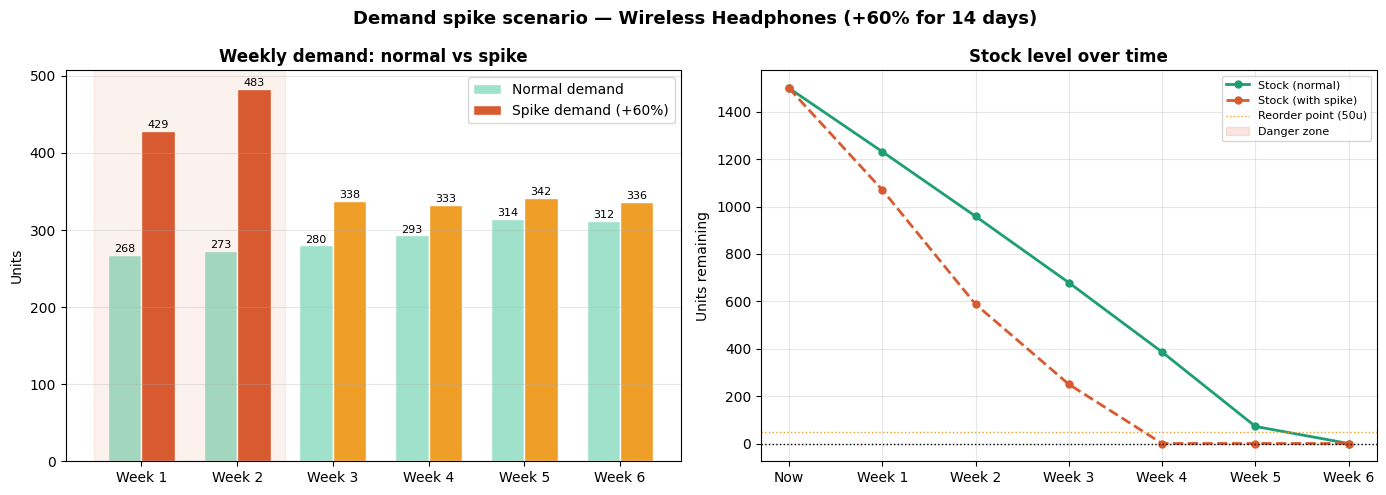

Graph saved: spike_Wireless_Headphones.png


ValueError: X has 15 features, but MinMaxScaler is expecting 16 features as input.

In [11]:
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import numpy as np
import torch
import joblib

# ═══════════════════════════════════════════════════════════════
# SCENARIO 1 — DEMAND SPIKE
# Simulates sudden surge in demand (flash sale, viral trend,
# festival, news event) and shows how warehouse must respond
# ═══════════════════════════════════════════════════════════════

def scenario_demand_spike(feature_dict, product_name,
                           spike_percent=50, spike_duration_days=7,
                           current_stock=240):
    """
    spike_percent:      how much demand increases e.g. 50 = +50%
    spike_duration_days: how many days the spike lasts
    current_stock:      units currently in warehouse
    """

    FEATURES = ['day_of_week','month','quarter','is_weekend',
                'is_month_start','is_month_end','lag_7','lag_14',
                'lag_30','lag_365','rolling_mean_7','rolling_mean_30','rolling_mean_90':73,
                'rolling_std_7','trend_direction','yoy_growth']

    def predict_one(f):
        arr    = np.array([[f[feat] for feat in FEATURES]])
        scaled = scaler_X.transform(arr)
        tensor = torch.FloatTensor(scaled).to(device)
        with torch.no_grad():
            raw = model(tensor)
        return round(float(scaler_y.inverse_transform(
            raw.cpu().numpy())[0][0]))

    def simulate_next_week(f, weekly_pred):
        f              = f.copy()
        daily          = weekly_pred / 7
        f['lag_30']    = f['lag_7']
        f['lag_14']    = f['lag_7']
        f['lag_7']     = daily
        f['rolling_mean_7']  = (f['rolling_mean_7']  * 6  + daily) / 7
        f['rolling_mean_30'] = (f['rolling_mean_30'] * 29 + daily) / 30
        f['trend_direction'] = f['lag_7'] - f['lag_30']
        f['day_of_week']     = (f['day_of_week'] + 7) % 7
        nm = f['month'] + 1 if f['month'] < 12 else 1
        f['month']           = nm
        f['quarter']         = (nm - 1) // 3 + 1
        f['is_weekend']      = 1 if f['day_of_week'] >= 5 else 0
        f['is_month_start']  = 0
        f['is_month_end']    = 0
        return f

    num_weeks      = 6
    normal_preds   = []
    spike_preds    = []
    spike_weeks    = max(1, round(spike_duration_days / 7))
    multiplier     = 1 + (spike_percent / 100)

    # ── Normal forecast (no spike) ────────────────────────────
    f_normal = feature_dict.copy()
    for _ in range(num_weeks):
        pred = predict_one(f_normal)
        normal_preds.append(pred)
        f_normal = simulate_next_week(f_normal, pred)

    # ── Spike forecast ────────────────────────────────────────
    f_spike = feature_dict.copy()
    for w in range(num_weeks):
        pred = predict_one(f_spike)
        if w < spike_weeks:
            pred = round(pred * multiplier)   # apply spike
        spike_preds.append(pred)
        f_spike = simulate_next_week(f_spike, pred)

    # ── Stockout analysis ─────────────────────────────────────
    stock_normal = current_stock
    stock_spike  = current_stock
    stockout_normal_week = None
    stockout_spike_week  = None

    for w in range(num_weeks):
        stock_normal -= normal_preds[w]
        stock_spike  -= spike_preds[w]
        if stock_normal < 0 and stockout_normal_week is None:
            stockout_normal_week = w + 1
        if stock_spike < 0 and stockout_spike_week is None:
            stockout_spike_week = w + 1

    total_normal    = sum(normal_preds)
    total_spike     = sum(spike_preds)
    extra_demand    = total_spike - total_normal
    restock_needed  = max(0, extra_demand)

    # ── Print results ─────────────────────────────────────────
    week_labels = [f'Week {i+1}' for i in range(num_weeks)]
    print("\n" + "="*65)
    print(f"SCENARIO: DEMAND SPIKE — {product_name}")
    print(f"Spike: +{spike_percent}% for {spike_duration_days} days")
    print("="*65)
    print(f"{'Week':<10} {'Normal':>12} {'With Spike':>12} {'Difference':>12}")
    print("-"*65)
    for w in range(num_weeks):
        diff = spike_preds[w] - normal_preds[w]
        flag = ' ← SPIKE' if w < spike_weeks else ''
        print(f"{week_labels[w]:<10} {normal_preds[w]:>10} u  "
              f"{spike_preds[w]:>10} u  {diff:>+10}{flag}")
    print("-"*65)
    print(f"{'TOTAL':<10} {total_normal:>10} u  {total_spike:>10} u  "
          f"{extra_demand:>+10}")
    print("="*65)
    print(f"\nStock analysis (starting stock: {current_stock} units):")
    print(f"  Without spike → stockout at: "
          f"{'Week ' + str(stockout_normal_week) if stockout_normal_week else 'No stockout'}")
    print(f"  With spike    → stockout at: "
          f"{'Week ' + str(stockout_spike_week) + ' ← CRITICAL' if stockout_spike_week else 'No stockout'}")
    print(f"  Extra units needed to cover spike: {restock_needed} units")
    print("="*65)

    # ── Graph ─────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Demand spike scenario — {product_name} '
                 f'(+{spike_percent}% for {spike_duration_days} days)',
                 fontsize=13, fontweight='bold')

    x = np.arange(num_weeks)

    # Chart 1 — side by side bars
    ax1 = axes[0]
    w   = 0.35
    b1  = ax1.bar(x - w/2, normal_preds, w,
                   label='Normal demand', color='#9FE1CB', edgecolor='white')
    b2  = ax1.bar(x + w/2, spike_preds, w,
                   label=f'Spike demand (+{spike_percent}%)',
                   color=['#D85A30' if i < spike_weeks else '#EF9F27'
                          for i in range(num_weeks)],
                   edgecolor='white')

    # Value labels
    for bar in b1:
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 str(int(bar.get_height())),
                 ha='center', va='bottom', fontsize=8)
    for bar in b2:
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 str(int(bar.get_height())),
                 ha='center', va='bottom', fontsize=8)

    ax1.set_title('Weekly demand: normal vs spike', fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(week_labels)
    ax1.set_ylabel('Units')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.axvspan(-0.5, spike_weeks - 0.5,
                alpha=0.08, color='#D85A30', label='Spike period')

    # Chart 2 — cumulative stock level
    ax2 = axes[1]
    cum_normal = [current_stock]
    cum_spike  = [current_stock]
    for w in range(num_weeks):
        cum_normal.append(max(0, cum_normal[-1] - normal_preds[w]))
        cum_spike.append(max(0, cum_spike[-1] - spike_preds[w]))

    x2 = list(range(num_weeks + 1))
    ax2.plot(x2, cum_normal, marker='o', color='#1D9E75',
             linewidth=2, label='Stock (normal)', markersize=5)
    ax2.plot(x2, cum_spike,  marker='o', color='#D85A30',
             linewidth=2, label='Stock (with spike)', markersize=5,
             linestyle='--')
    ax2.axhline(y=0, color='black', linewidth=1, linestyle=':')
    ax2.axhline(y=50, color='#EF9F27', linewidth=1,
                linestyle=':', label='Reorder point (50u)')
    ax2.fill_between(x2, cum_spike, 0,
                     where=[s < 50 for s in cum_spike],
                     alpha=0.15, color='#D85A30', label='Danger zone')
    ax2.set_title('Stock level over time', fontweight='bold')
    ax2.set_xticks(x2)
    ax2.set_xticklabels(['Now'] + week_labels)
    ax2.set_ylabel('Units remaining')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    fname = f"spike_{product_name.replace(' ','_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Graph saved: {fname}")

    return {
        'normal_weekly':      normal_preds,
        'spike_weekly':       spike_preds,
        'extra_demand':       extra_demand,
        'restock_needed':     restock_needed,
        'stockout_week_normal': stockout_normal_week,
        'stockout_week_spike':  stockout_spike_week
    }


# ═══════════════════════════════════════════════════════════════
# SCENARIO 2 — SUPPLY DELAY
# Simulates supplier failing to deliver on time and shows
# exactly when stockout happens and what the damage is
# ═══════════════════════════════════════════════════════════════

def scenario_supply_delay(feature_dict, product_name,
                           current_stock=240,
                           expected_restock_units=200,
                           expected_restock_week=2,
                           delay_weeks=3):
    """
    expected_restock_units: how many units were supposed to arrive
    expected_restock_week:  which week the restock was planned
    delay_weeks:            how many weeks late the supplier is
    """

    FEATURES = ['day_of_week','month','quarter','is_weekend',
                'is_month_start','is_month_end','lag_7','lag_14',
                'lag_30','lag_365','rolling_mean_7','rolling_mean_30',
                'rolling_std_7','trend_direction','yoy_growth']

    def predict_one(f):
        arr    = np.array([[f[feat] for feat in FEATURES]])
        scaled = scaler_X.transform(arr)
        tensor = torch.FloatTensor(scaled).to(device)
        with torch.no_grad():
            raw = model(tensor)
        return round(float(scaler_y.inverse_transform(
            raw.cpu().numpy())[0][0]))

    def simulate_next_week(f, weekly_pred):
        f              = f.copy()
        daily          = weekly_pred / 7
        f['lag_30']    = f['lag_7']
        f['lag_14']    = f['lag_7']
        f['lag_7']     = daily
        f['rolling_mean_7']  = (f['rolling_mean_7']  * 6  + daily) / 7
        f['rolling_mean_30'] = (f['rolling_mean_30'] * 29 + daily) / 30
        f['trend_direction'] = f['lag_7'] - f['lag_30']
        f['day_of_week']     = (f['day_of_week'] + 7) % 7
        nm = f['month'] + 1 if f['month'] < 12 else 1
        f['month']           = nm
        f['quarter']         = (nm - 1) // 3 + 1
        f['is_weekend']      = 1 if f['day_of_week'] >= 5 else 0
        f['is_month_start']  = 0
        f['is_month_end']    = 0
        return f

    num_weeks     = 8
    actual_restock_week = expected_restock_week + delay_weeks

    # Predict demand for all 8 weeks
    demand_preds = []
    f = feature_dict.copy()
    for _ in range(num_weeks):
        pred = predict_one(f)
        demand_preds.append(pred)
        f = simulate_next_week(f, pred)

    # ── Simulate stock with ON TIME delivery ──────────────────
    stock_ontime = [current_stock]
    for w in range(num_weeks):
        prev = stock_ontime[-1]
        if w + 1 == expected_restock_week:
            prev += expected_restock_units    # restock arrives on time
        stock_ontime.append(max(0, prev - demand_preds[w]))

    # ── Simulate stock with DELAYED delivery ──────────────────
    stock_delayed = [current_stock]
    lost_sales    = []
    for w in range(num_weeks):
        prev = stock_delayed[-1]
        if w + 1 == actual_restock_week:
            prev += expected_restock_units    # restock arrives late
        sold        = min(prev, demand_preds[w])
        lost        = demand_preds[w] - sold  # units lost due to no stock
        stock_delayed.append(max(0, prev - sold))
        lost_sales.append(lost)

    # ── Analytics ─────────────────────────────────────────────
    total_lost       = sum(lost_sales)
    stockout_week    = next((w+1 for w, s in
                             enumerate(stock_delayed[1:]) if s == 0), None)
    recovery_week    = actual_restock_week

    # ── Print results ─────────────────────────────────────────
    week_labels = [f'Week {i+1}' for i in range(num_weeks)]
    print("\n" + "="*70)
    print(f"SCENARIO: SUPPLY DELAY — {product_name}")
    print(f"Restock of {expected_restock_units} units expected Week "
          f"{expected_restock_week}, delayed by {delay_weeks} weeks "
          f"(arrives Week {actual_restock_week})")
    print("="*70)
    print(f"{'Week':<10} {'Demand':>10} {'OnTime Stock':>14} "
          f"{'Delayed Stock':>14} {'Lost Sales':>12}")
    print("-"*70)
    for w in range(num_weeks):
        ot_flag = ' ← RESTOCK' if w+1 == expected_restock_week else ''
        dl_flag = ' ← DELAYED RESTOCK' if w+1 == actual_restock_week else ''
        ls_flag = f' ← {lost_sales[w]} LOST' if lost_sales[w] > 0 else ''
        print(f"Week {w+1:<5} {demand_preds[w]:>10} u  "
              f"{stock_ontime[w+1]:>12} u{ot_flag:15}"
              f"{stock_delayed[w+1]:>12} u{dl_flag:20}"
              f"{lost_sales[w]:>10}{ls_flag}")
    print("="*70)
    print(f"\nImpact summary:")
    print(f"  Stockout starts:    Week {stockout_week if stockout_week else 'Never'}")
    print(f"  Recovery week:      Week {recovery_week}")
    print(f"  Total lost sales:   {total_lost} units")
    print(f"  WareBot action:     {'EMERGENCY REORDER REQUIRED' if total_lost > 0 else 'Manageable'}")
    print("="*70)

    # ── Graph ─────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        f'Supply delay scenario — {product_name} '
        f'(Restock delayed {delay_weeks} weeks)',
        fontsize=13, fontweight='bold'
    )

    x = list(range(num_weeks + 1))

    # Chart 1 — Stock levels comparison
    ax1 = axes[0]
    ax1.plot(x, stock_ontime,  marker='o', color='#1D9E75',
             linewidth=2.5, label='On-time delivery', markersize=6)
    ax1.plot(x, stock_delayed, marker='o', color='#D85A30',
             linewidth=2.5, label=f'Delayed by {delay_weeks} weeks',
             linestyle='--', markersize=6)

    # Mark restock events
    ax1.axvline(x=expected_restock_week, color='#1D9E75',
                linestyle=':', alpha=0.7, linewidth=1.5)
    ax1.axvline(x=actual_restock_week, color='#D85A30',
                linestyle=':', alpha=0.7, linewidth=1.5)
    ax1.text(expected_restock_week + 0.1, max(stock_ontime) * 0.9,
             'Planned\nrestock', fontsize=8, color='#1D9E75')
    ax1.text(actual_restock_week + 0.1, max(stock_ontime) * 0.75,
             'Actual\nrestock', fontsize=8, color='#D85A30')

    ax1.axhline(y=0,  color='black',   linewidth=1, linestyle=':')
    ax1.axhline(y=50, color='#EF9F27', linewidth=1,
                linestyle=':', label='Reorder point')
    ax1.fill_between(x, stock_delayed, 0,
                     where=[s == 0 for s in stock_delayed],
                     alpha=0.2, color='#D85A30', label='Stockout period')
    ax1.set_title('Stock level: on-time vs delayed', fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(['Now'] + week_labels, rotation=30, ha='right')
    ax1.set_ylabel('Units in stock')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)

    # Chart 2 — Lost sales per week
    ax2  = axes[1]
    bar_colors = ['#D85A30' if ls > 0 else '#9FE1CB' for ls in lost_sales]
    bars = ax2.bar(week_labels, lost_sales, color=bar_colors, edgecolor='white')
    for bar, ls in zip(bars, lost_sales):
        if ls > 0:
            ax2.text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.5,
                     f'{ls}u', ha='center', va='bottom',
                     fontsize=9, fontweight='bold', color='#993C1D')
    ax2.set_title(f'Lost sales per week (total: {total_lost} units)',
                  fontweight='bold')
    ax2.set_ylabel('Units lost')
    ax2.set_xticklabels(week_labels, rotation=30, ha='right')
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.text(0.5, 0.95,
             f'Total lost: {total_lost} units\n'
             f'Stockout: Week {stockout_week or "None"}\n'
             f'Recovery: Week {recovery_week}',
             transform=ax2.transAxes,
             ha='center', va='top', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='#FAECE7',
                       edgecolor='#F5C4B3', alpha=0.9),
             color='#712B13')

    plt.tight_layout()
    fname = f"supply_delay_{product_name.replace(' ','_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Graph saved: {fname}")

    return {
        'demand_weekly':      demand_preds,
        'stock_ontime':       stock_ontime,
        'stock_delayed':      stock_delayed,
        'lost_sales_weekly':  lost_sales,
        'total_lost':         total_lost,
        'stockout_week':      stockout_week,
        'recovery_week':      recovery_week
    }


# ═══════════════════════════════════════════════════════════════
# TEST ALL SCENARIOS
# ═══════════════════════════════════════════════════════════════

headphones = {
    'day_of_week':1,'month':12,'quarter':4,'is_weekend':0,
    'is_month_start':0,'is_month_end':1,'lag_7':48,'lag_14':44,
    'lag_30':41,'lag_365':31,'rolling_mean_7':44.2,'rolling_mean_90':73,
    'rolling_mean_30':39.7,'rolling_std_7':4.1,
    'trend_direction':7.0,'yoy_growth':0.61
}

# Scenario 1 — Flash sale causes 60% spike for 2 weeks
scenario_demand_spike(
    feature_dict      = headphones,
    product_name      = 'Wireless Headphones',
    spike_percent     = 60,
    spike_duration_days = 14,
    current_stock     = 1500
)

# Scenario 2 — Supplier delayed by 3 weeks
scenario_supply_delay(
    feature_dict            = headphones,
    product_name            = 'Wireless Headphones',
    current_stock           = 800,
    expected_restock_units  = 1000,
    expected_restock_week   = 2,
    delay_weeks             = 3
)

In [ ]:
# ═══════════════════════════════════════════════════════════════
# SCENARIO 3 — SEASONAL SURGE
# Simulates a festival/holiday season causing gradual demand
# build-up over multiple weeks, peaks, then tapers back down
# Real world: Diwali, Christmas, Back-to-school, IPL season
# ═══════════════════════════════════════════════════════════════

def scenario_seasonal_surge(feature_dict, product_name,
                             current_stock=1500,
                             season_name='Diwali',
                             peak_week=3,
                             peak_boost_percent=120,
                             season_duration_weeks=6,
                             user_min=30, user_max=52):
    """
    peak_week:            which week demand hits maximum
    peak_boost_percent:   how much higher than normal at peak
    season_duration_weeks: total length of seasonal period
    """

    FEATURES = ['day_of_week','month','quarter','is_weekend',
                'is_month_start','is_month_end','lag_7','lag_14',
                'lag_30','lag_365','rolling_mean_7','rolling_mean_30',
                'rolling_std_7','trend_direction','yoy_growth']

    def predict_one(f):
        arr    = np.array([[f[feat] for feat in FEATURES]])
        scaled = scaler_X.transform(arr)
        tensor = torch.FloatTensor(scaled).to(device)
        with torch.no_grad():
            raw = model(tensor)
        normalized = float(raw.cpu().numpy()[0][0])
        daily      = (normalized * (user_max - user_min)) + user_min
        return round(daily * 7)

    def simulate_next_week(f, weekly_pred):
        f           = f.copy()
        daily       = weekly_pred / 7
        f['lag_30'] = f['lag_7']
        f['lag_14'] = f['lag_7']
        f['lag_7']  = daily
        f['rolling_mean_7']  = (f['rolling_mean_7']  * 6  + daily) / 7
        f['rolling_mean_30'] = (f['rolling_mean_30'] * 29 + daily) / 30
        f['trend_direction'] = f['lag_7'] - f['lag_30']
        f['day_of_week']     = (f['day_of_week'] + 7) % 7
        nm = f['month'] + 1 if f['month'] < 12 else 1
        f['month']           = nm
        f['quarter']         = (nm - 1) // 3 + 1
        f['is_weekend']      = 1 if f['day_of_week'] >= 5 else 0
        f['is_month_start']  = 0
        f['is_month_end']    = 0
        return f

    # Build seasonal multiplier curve
    # Gradual build-up → peak → taper down (bell curve shape)
    multipliers = []
    for w in range(season_duration_weeks):
        week_num = w + 1
        if week_num <= peak_week:
            # Build up phase
            progress = week_num / peak_week
            boost    = (peak_boost_percent / 100) * progress
        else:
            # Taper down phase
            remaining  = season_duration_weeks - peak_week
            progress   = (week_num - peak_week) / remaining
            boost      = (peak_boost_percent / 100) * (1 - progress)
        multipliers.append(1 + boost)

    # ── Normal forecast ───────────────────────────────────────
    normal_preds = []
    f_normal     = feature_dict.copy()
    for _ in range(season_duration_weeks):
        pred = predict_one(f_normal)
        normal_preds.append(pred)
        f_normal = simulate_next_week(f_normal, pred)

    # ── Seasonal surge forecast ───────────────────────────────
    surge_preds = []
    f_surge     = feature_dict.copy()
    for w in range(season_duration_weeks):
        pred = predict_one(f_surge)
        pred = round(pred * multipliers[w])
        surge_preds.append(pred)
        f_surge = simulate_next_week(f_surge, pred)

    # ── Stock simulation ──────────────────────────────────────
    stock_normal = [current_stock]
    stock_surge  = [current_stock]
    for w in range(season_duration_weeks):
        stock_normal.append(max(0, stock_normal[-1] - normal_preds[w]))
        stock_surge.append( max(0, stock_surge[-1]  - surge_preds[w]))

    stockout_week   = next((w+1 for w, s in
                            enumerate(stock_surge[1:]) if s <= 0), None)
    total_normal    = sum(normal_preds)
    total_surge     = sum(surge_preds)
    extra_needed    = max(0, total_surge - current_stock)
    peak_demand     = max(surge_preds)
    peak_week_actual= surge_preds.index(peak_demand) + 1

    # ── Print ─────────────────────────────────────────────────
    week_labels = [f'Week {i+1}' for i in range(season_duration_weeks)]
    print("\n" + "="*70)
    print(f"SCENARIO: SEASONAL SURGE — {product_name} ({season_name})")
    print(f"Peak at Week {peak_week} with +{peak_boost_percent}% boost")
    print("="*70)
    print(f"{'Week':<10} {'Multiplier':>12} {'Normal':>10} "
          f"{'Surge':>10} {'Difference':>12}")
    print("-"*70)
    for w in range(season_duration_weeks):
        diff  = surge_preds[w] - normal_preds[w]
        pflag = ' ← PEAK' if w+1 == peak_week_actual else ''
        print(f"Week {w+1:<5} {multipliers[w]:>10.2f}x  "
              f"{normal_preds[w]:>8} u  "
              f"{surge_preds[w]:>8} u  "
              f"{diff:>+10}{pflag}")
    print("="*70)
    print(f"\nSeason summary:")
    print(f"  Peak demand week:  Week {peak_week_actual} "
          f"({peak_demand} units)")
    print(f"  Total normal:      {total_normal} units")
    print(f"  Total surge:       {total_surge} units")
    print(f"  Extra needed:      {extra_needed} units above current stock")
    print(f"  Stockout at:       "
          f"{'Week ' + str(stockout_week) + ' ← RESTOCK NEEDED' if stockout_week else 'No stockout'}")
    print("="*70)

    # ── Graph ─────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(
        f'Seasonal surge — {product_name} ({season_name}) '
        f'Peak: +{peak_boost_percent}% at Week {peak_week}',
        fontsize=13, fontweight='bold'
    )

    x = np.arange(season_duration_weeks)

    # Chart 1 — demand curve with surge shape
    ax1 = axes[0]
    ax1.fill_between(range(season_duration_weeks),
                     normal_preds, surge_preds,
                     alpha=0.25, color='#D85A30', label='Surge extra demand')
    ax1.plot(range(season_duration_weeks), normal_preds,
             marker='o', color='#1D9E75', linewidth=2,
             label='Normal demand', markersize=5)
    ax1.plot(range(season_duration_weeks), surge_preds,
             marker='o', color='#D85A30', linewidth=2.5,
             label=f'{season_name} surge', markersize=6)
    ax1.axvline(x=peak_week - 1, color='#EF9F27',
                linestyle='--', linewidth=1.5, alpha=0.8)
    ax1.text(peak_week - 0.9, max(surge_preds) * 0.95,
             f'Peak\nWeek {peak_week}', fontsize=8,
             color='#854F0B')
    ax1.set_title('Demand: normal vs seasonal surge', fontweight='bold')
    ax1.set_xticks(range(season_duration_weeks))
    ax1.set_xticklabels(week_labels, rotation=30, ha='right')
    ax1.set_ylabel('Units')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)

    # Chart 2 — multiplier curve (the season shape)
    ax2 = axes[1]
    mult_colors = ['#D85A30' if m == max(multipliers)
                   else '#EF9F27' if m > 1.5
                   else '#9FE1CB' for m in multipliers]
    bars = ax2.bar(week_labels, multipliers,
                   color=mult_colors, edgecolor='white', width=0.6)
    for bar, m in zip(bars, multipliers):
        ax2.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f'{m:.2f}x', ha='center', va='bottom', fontsize=9)
    ax2.axhline(y=1.0, color='#1D9E75', linewidth=1.5,
                linestyle='--', label='Normal (1.0x)')
    ax2.set_title(f'{season_name} demand multiplier curve',
                  fontweight='bold')
    ax2.set_ylabel('Demand multiplier')
    ax2.set_xticklabels(week_labels, rotation=30, ha='right')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')

    # Chart 3 — stock levels
    ax3 = axes[2]
    x3  = list(range(season_duration_weeks + 1))
    ax3.plot(x3, stock_normal, marker='o', color='#1D9E75',
             linewidth=2, label='Stock (normal)', markersize=5)
    ax3.plot(x3, stock_surge,  marker='o', color='#D85A30',
             linewidth=2, label='Stock (surge)',
             linestyle='--', markersize=5)
    ax3.axhline(y=0,  color='black', linewidth=1, linestyle=':')
    ax3.axhline(y=current_stock * 0.2, color='#EF9F27',
                linewidth=1, linestyle=':', label='20% safety stock')
    if stockout_week:
        ax3.axvline(x=stockout_week, color='#D85A30',
                    linestyle=':', linewidth=1.5, alpha=0.7)
        ax3.text(stockout_week + 0.1,
                 max(stock_surge) * 0.5,
                 f'Stockout\nWeek {stockout_week}',
                 fontsize=8, color='#D85A30')
    ax3.set_title('Stock depletion during season', fontweight='bold')
    ax3.set_xticks(x3)
    ax3.set_xticklabels(['Now'] + week_labels, rotation=30, ha='right')
    ax3.set_ylabel('Units remaining')
    ax3.legend(fontsize=8)
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    fname = f"seasonal_{season_name}_{product_name.replace(' ','_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Graph saved: {fname}")

    return {
        'normal_weekly':   normal_preds,
        'surge_weekly':    surge_preds,
        'multipliers':     multipliers,
        'peak_week':       peak_week_actual,
        'peak_demand':     peak_demand,
        'total_surge':     total_surge,
        'extra_needed':    extra_needed,
        'stockout_week':   stockout_week,
        'stock_levels':    stock_surge
    }


# ═══════════════════════════════════════════════════════════════
# SCENARIO 4 — NEW PRODUCT LAUNCH
# Simulates adding a brand new product to the warehouse with
# zero history. Shows demand ramp-up curve from zero,
# recommends which rack to place it based on predicted growth,
# and tells you how much initial stock to order
# ═══════════════════════════════════════════════════════════════

def scenario_new_product_launch(product_name,
                                 category='Electronics',
                                 launch_week_month=3,
                                 initial_stock=500,
                                 growth_rate_percent=15,
                                 num_weeks=8,
                                 user_min=30, user_max=52):
    """
    category:             Electronics / Perishables / Bulk / Fragile
    launch_week_month:    which month of year launch happens (1-12)
    initial_stock:        how many units to put in on day 1
    growth_rate_percent:  expected week-over-week growth during ramp-up
    """

    FEATURES = ['day_of_week','month','quarter','is_weekend',
                'is_month_start','is_month_end','lag_7','lag_14',
                'lag_30','lag_365','rolling_mean_7','rolling_mean_30',
                'rolling_std_7','trend_direction','yoy_growth']

    # Category baseline daily sales (from your classifier training data)
    category_baselines = {
        'Electronics': {'daily_avg': 35, 'volatility': 0.25,
                        'seasonal_q4_boost': 1.4},
        'Perishables':  {'daily_avg': 80, 'volatility': 0.15,
                         'seasonal_q4_boost': 1.2},
        'Bulk':         {'daily_avg': 20, 'volatility': 0.10,
                         'seasonal_q4_boost': 1.1},
        'Fragile':      {'daily_avg': 12, 'volatility': 0.30,
                         'seasonal_q4_boost': 1.3},
    }

    baseline = category_baselines.get(category,
               category_baselines['Electronics'])

    # Month seasonal index — model learned these patterns
    month_index = {
        1:0.70, 2:0.65, 3:0.75, 4:0.80, 5:0.85,
        6:0.90, 7:0.92, 8:1.00, 9:1.05,
        10:1.20, 11:1.40, 12:1.60
    }

    # ── Simulate ramp-up demand week by week ─────────────────
    # New product starts at 30% of category baseline
    # Grows by growth_rate_percent each week (adoption curve)
    # Seasonal modifier applied on top

    ramp_preds   = []
    confidence   = []
    current_month = launch_week_month

    base_daily  = baseline['daily_avg'] * 0.30  # start at 30% of baseline

    for w in range(num_weeks):
        # Apply growth rate
        if w > 0:
            base_daily = base_daily * (1 + growth_rate_percent / 100)

        # Cap at 110% of category baseline (maturity ceiling)
        base_daily = min(base_daily, baseline['daily_avg'] * 1.10)

        # Apply seasonal modifier
        seasonal_mod = month_index.get(current_month, 1.0)
        weekly_pred  = round(base_daily * 7 * seasonal_mod)
        ramp_preds.append(weekly_pred)

        # Confidence grows as product gets more history
        conf = min(85, 35 + (w * 7))  # starts low, grows each week
        confidence.append(conf)

        # Advance month
        if (w + 1) % 4 == 0:
            current_month = current_month + 1 if current_month < 12 else 1

    # ── Build a feature dict for the model after 4 weeks ─────
    # By week 4 we have enough data to start using the real model
    week4_daily = ramp_preds[3] / 7 if len(ramp_preds) >= 4 else base_daily

    model_features = {
        'day_of_week':    0,
        'month':          launch_week_month,
        'quarter':        (launch_week_month - 1) // 3 + 1,
        'is_weekend':     0,
        'is_month_start': 0,
        'is_month_end':   0,
        'lag_7':          week4_daily,
        'lag_14':         week4_daily * 0.85,
        'lag_30':         week4_daily * 0.65,
        'lag_365':        0,     # no last year data for new product
        'rolling_mean_7': week4_daily * 0.95,
        'rolling_mean_30':week4_daily * 0.70,
        'rolling_std_7':  week4_daily * baseline['volatility'],
        'trend_direction':week4_daily * 0.35,
        'yoy_growth':     0      # no YoY for new product
    }

    arr    = np.array([[model_features[f] for f in FEATURES]])
    scaled = scaler_X.transform(arr)
    tensor = torch.FloatTensor(scaled).to(device)
    with torch.no_grad():
        raw = model(tensor)
    normalized    = float(raw.cpu().numpy()[0][0])
    model_weekly  = round(
        ((normalized * (user_max - user_min)) + user_min) * 7
    )

    # Blend ramp prediction with model prediction for week 5+
    for w in range(4, num_weeks):
        blend_weight  = min(1.0, (w - 3) * 0.25)
        blended       = round(
            ramp_preds[w] * (1 - blend_weight) +
            model_weekly   * blend_weight
        )
        ramp_preds[w] = blended

    # ── Stock simulation ──────────────────────────────────────
    stock_levels   = [initial_stock]
    restock_events = []
    for w in range(num_weeks):
        remaining = stock_levels[-1] - ramp_preds[w]
        if remaining < initial_stock * 0.20:
            # Auto-restock at 20% threshold
            restock_qty = initial_stock
            remaining  += restock_qty
            restock_events.append(
                {'week': w+1, 'qty': restock_qty}
            )
        stock_levels.append(max(0, remaining))

    # ── Rack recommendation ───────────────────────────────────
    avg_weekly     = sum(ramp_preds) / num_weeks
    mature_weekly  = ramp_preds[-1]

    if mature_weekly > baseline['daily_avg'] * 7 * 0.8:
        recommended_rack = 'Rack 1A or 1B'
        rack_reason      = 'High mature demand — place near terminal'
        rack_zone        = 'CLOSE TO TERMINAL'
    elif mature_weekly > baseline['daily_avg'] * 7 * 0.5:
        recommended_rack = 'Rack 2A or 2B'
        rack_reason      = 'Medium demand — mid-distance placement'
        rack_zone        = 'MID ZONE'
    else:
        recommended_rack = 'Rack 3A or 3B'
        rack_reason      = 'Low demand — further from terminal is fine'
        rack_zone        = 'FAR ZONE'

    # ── Print ─────────────────────────────────────────────────
    week_labels = [f'Week {i+1}' for i in range(num_weeks)]
    print("\n" + "="*70)
    print(f"SCENARIO: NEW PRODUCT LAUNCH — {product_name}")
    print(f"Category: {category} | "
          f"Launch month: {launch_week_month} | "
          f"Growth rate: +{growth_rate_percent}%/week")
    print("="*70)
    print(f"{'Week':<10} {'Predicted':>12} {'Confidence':>12} "
          f"{'Stock After':>14}")
    print("-"*70)
    for w in range(num_weeks):
        re_flag = ''
        for re in restock_events:
            if re['week'] == w + 1:
                re_flag = f' + {re["qty"]} restock'
        print(f"Week {w+1:<5} {ramp_preds[w]:>10} u  "
              f"{confidence[w]:>10}%  "
              f"{stock_levels[w+1]:>12} u{re_flag}")
    print("="*70)
    print(f"\nLaunch analysis:")
    print(f"  Initial stock order:     {initial_stock} units")
    print(f"  Week 1 demand:           {ramp_preds[0]} units "
          f"(30% of {category} baseline)")
    print(f"  Week {num_weeks} demand (mature):  {ramp_preds[-1]} units")
    print(f"  Avg weekly demand:       {round(avg_weekly)} units")
    print(f"  Restock events:          {len(restock_events)}")
    print(f"\nAI rack recommendation:")
    print(f"  Recommended rack:        {recommended_rack}")
    print(f"  Zone:                    {rack_zone}")
    print(f"  Reason:                  {rack_reason}")
    print(f"\nConfidence note:")
    print(f"  Week 1-3: low confidence (35-56%) — no sales history yet")
    print(f"  Week 4+:  model takes over as real data accumulates")
    print("="*70)

    # ── Graph ─────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(
        f'New product launch — {product_name} '
        f'({category}, Month {launch_week_month}, '
        f'+{growth_rate_percent}%/week growth)',
        fontsize=13, fontweight='bold'
    )

    x = np.arange(num_weeks)

    # Chart 1 — ramp-up demand curve
    ax1 = axes[0]
    bar_colors = ['#B5D4F4' if w < 3 else '#378ADD'
                  for w in range(num_weeks)]
    bars = ax1.bar(week_labels, ramp_preds,
                   color=bar_colors, edgecolor='white', width=0.6)
    for bar, pred in zip(bars, ramp_preds):
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{pred}u', ha='center', va='bottom', fontsize=8)

    # Mark category baseline
    baseline_weekly = round(baseline['daily_avg'] * 7)
    ax1.axhline(y=baseline_weekly, color='#1D9E75',
                linewidth=1.5, linestyle='--',
                label=f'{category} baseline ({baseline_weekly}u/wk)')
    ax1.axvline(x=2.5, color='#EF9F27', linewidth=1.5,
                linestyle=':', alpha=0.8)
    ax1.text(2.6, max(ramp_preds) * 0.95,
             'Model\ntakes over', fontsize=8, color='#854F0B')
    ax1.set_title('Demand ramp-up curve', fontweight='bold')
    ax1.set_ylabel('Units per week')
    ax1.set_xticklabels(week_labels, rotation=30, ha='right')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3, axis='y')
    # Legend for bar colors
    from matplotlib.patches import Patch
    ax1.legend(handles=[
        Patch(color='#B5D4F4', label='Category estimate (low conf)'),
        Patch(color='#378ADD', label='Model prediction (higher conf)'),
        Patch(color='#1D9E75', label=f'Baseline {baseline_weekly}u')
    ], fontsize=8)

    # Chart 2 — confidence over time
    ax2 = axes[1]
    ax2.fill_between(range(num_weeks), confidence,
                     alpha=0.3, color='#1D9E75')
    ax2.plot(range(num_weeks), confidence,
             marker='o', color='#1D9E75', linewidth=2, markersize=6)
    ax2.axhline(y=80, color='#EF9F27', linewidth=1,
                linestyle='--', label='Target 80% confidence')
    ax2.axvline(x=3, color='#378ADD', linewidth=1,
                linestyle=':', alpha=0.8,
                label='Model kicks in (Week 4)')
    for w in range(num_weeks):
        ax2.text(w, confidence[w] + 1.5,
                 f'{confidence[w]}%', ha='center',
                 va='bottom', fontsize=8)
    ax2.set_title('Prediction confidence over time', fontweight='bold')
    ax2.set_xticks(range(num_weeks))
    ax2.set_xticklabels(week_labels, rotation=30, ha='right')
    ax2.set_ylabel('Confidence %')
    ax2.set_ylim(0, 100)
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

    # Chart 3 — stock level with restock events
    ax3 = axes[2]
    x3  = list(range(num_weeks + 1))
    ax3.plot(x3, stock_levels, marker='o', color='#378ADD',
             linewidth=2.5, markersize=6, label='Stock level')
    ax3.fill_between(x3, stock_levels, 0, alpha=0.1, color='#378ADD')
    ax3.axhline(y=initial_stock * 0.20, color='#EF9F27',
                linewidth=1.5, linestyle='--',
                label=f'Reorder point ({round(initial_stock*0.2)}u)')

    for re in restock_events:
        ax3.axvline(x=re['week'], color='#1D9E75',
                    linestyle=':', linewidth=1.5, alpha=0.8)
        ax3.text(re['week'] + 0.1,
                 max(stock_levels) * 0.85,
                 f'+{re["qty"]}u\nrestock',
                 fontsize=8, color='#0F6E56')

    # Rack recommendation box
    ax3.text(0.97, 0.97,
             f'AI recommends:\n{recommended_rack}\n{rack_zone}',
             transform=ax3.transAxes,
             ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round',
                       facecolor='#E1F5EE',
                       edgecolor='#9FE1CB', alpha=0.9),
             color='#085041')

    ax3.set_title('Stock level + auto-restock events', fontweight='bold')
    ax3.set_xticks(x3)
    ax3.set_xticklabels(['Launch'] + week_labels,
                        rotation=30, ha='right')
    ax3.set_ylabel('Units in stock')
    ax3.legend(fontsize=8)
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    fname = f"launch_{product_name.replace(' ','_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Graph saved: {fname}")

    return {
        'weekly_demand':      ramp_preds,
        'confidence':         confidence,
        'stock_levels':       stock_levels,
        'restock_events':     restock_events,
        'recommended_rack':   recommended_rack,
        'rack_zone':          rack_zone,
        'initial_stock_order': initial_stock,
        'mature_weekly':      ramp_preds[-1]
    }


# ═══════════════════════════════════════════════════════════════
# TEST BOTH SCENARIOS
# ═══════════════════════════════════════════════════════════════

headphones = {
    'day_of_week':1,'month':10,'quarter':4,'is_weekend':0,
    'is_month_start':0,'is_month_end':0,'lag_7':48,'lag_14':44,
    'lag_30':41,'lag_365':31,'rolling_mean_7':44.2,
    'rolling_mean_30':39.7,'rolling_std_7':4.1,
    'trend_direction':7.0,'yoy_growth':0.61
}

# Scenario 3 — Diwali season causes 120% peak at week 3
scenario_seasonal_surge(
    feature_dict          = headphones,
    product_name          = 'Wireless Headphones',
    current_stock         = 1500,
    season_name           = 'Diwali',
    peak_week             = 3,
    peak_boost_percent    = 120,
    season_duration_weeks = 6,
    user_min              = 30,
    user_max              = 52
)

# Scenario 4 — New product launching in October
scenario_new_product_launch(
    product_name          = 'Smart Watch Pro',
    category              = 'Electronics',
    launch_week_month     = 10,
    initial_stock         = 500,
    growth_rate_percent   = 15,
    num_weeks             = 8,
    user_min              = 30,
    user_max              = 52
)